In [1]:
# displays static in notebook
#%matplotlib inline  

# functions for file handling
import re as re
import os as os
from glob import glob

# math and stats
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy import units as u
from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.time import Time

from astropy.wcs import WCS

import cv2
from skimage import data, color
from skimage.registration import phase_cross_correlation
from skimage.registration._phase_cross_correlation import _upsampled_dft
from scipy.ndimage import fourier_shift
from skimage.transform import warp_polar, rotate, rescale, warp_coords, AffineTransform, warp

# point source identification and photometry
from photutils.detection import DAOStarFinder
from photutils.psf import PSFPhotometry

# graphics and plotting
import matplotlib.pyplot as plt


# I/O
from astropy.io import fits
import requests
from pathlib import Path

# point source identification and photometry
from photutils.detection import DAOStarFinder
from photutils.psf import PSFPhotometry



In [ ]:
# lightcurve analysis for BASW 1, the first Cepheid noted by Hubble in the Andromeda galaxy
# 00 41 27.3109287864 +41 10 10.505189352

# quick calculation for PanSTARRS using results from Kodric et al. 2018
#  https://vizier.cfa.harvard.edu/viz-bin/VizieR?-source=J/AJ/156/130
#  PSO J010.3637+41.1696
#  period: 31.376577
#  de-reddened rmag: 18.5292
#  de-reddened gmag: 18.9791
#  PL from table 4:  r PS1 slope -2.368, a(logP=1) = 20.336:  expected rmag 19.2
#  PL from table 4:  g PS1 slope -2.021, a(logP=1) = 20.799:  expected gmag 19.8
#  Andromeda distance modulus 24.36 mag (Vilardell et al. 2010)




In [3]:
infile = 'BASW1-lightcurve.fits'

hdu = fits.open(infile)

hdu.info()


Filename: BASW1-lightcurve.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Table         1 BinTableHDU     81   910R x 24C   [1K, 1J, 1D, 1D, 1E, 1E, 1J, 2A, 1D, 1D, 1E, 1E, 1K, 1J, 1B, 1B, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J]   


In [5]:
data = hdu[1].data
columns = hdu[1].columns
print(columns)

ColDefs(
    name = 'oid'; format = '1K'; null = 9223372036854775807
    name = 'expid'; format = '1J'; null = 2147483647
    name = 'hjd'; format = '1D'; unit = 'd'
    name = 'mjd'; format = '1D'; unit = 'd'
    name = 'mag'; format = '1E'; unit = 'mag'
    name = 'magerr'; format = '1E'; unit = 'mag'
    name = 'catflags'; format = '1J'; null = 2147483647
    name = 'filtercode'; format = '2A'
    name = 'ra'; format = '1D'; unit = 'deg'
    name = 'dec'; format = '1D'; unit = 'deg'
    name = 'chi'; format = '1E'
    name = 'sharp'; format = '1E'
    name = 'filefracday'; format = '1K'; null = 9223372036854775807
    name = 'field'; format = '1J'; null = 2147483647
    name = 'ccdid'; format = '1B'; null = 255
    name = 'qid'; format = '1B'; null = 255
    name = 'limitmag'; format = '1E'; unit = 'mag'
    name = 'magzp'; format = '1E'; unit = 'mag'
    name = 'magzprms'; format = '1E'; unit = 'mag'
    name = 'clrcoeff'; format = '1E'
    name = 'clrcounc'; format = '1E'
    name

(20.7, 18.4)

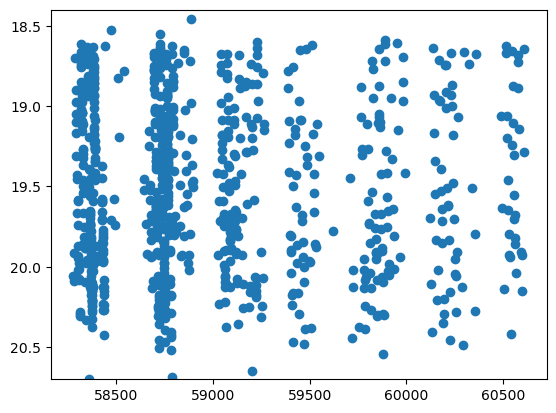

In [7]:
mjd = data['mjd']
mags = data['mag']
magerrs = data['magerr']

plt.scatter(mjd, mags)
plt.ylim(20.7, 18.4)

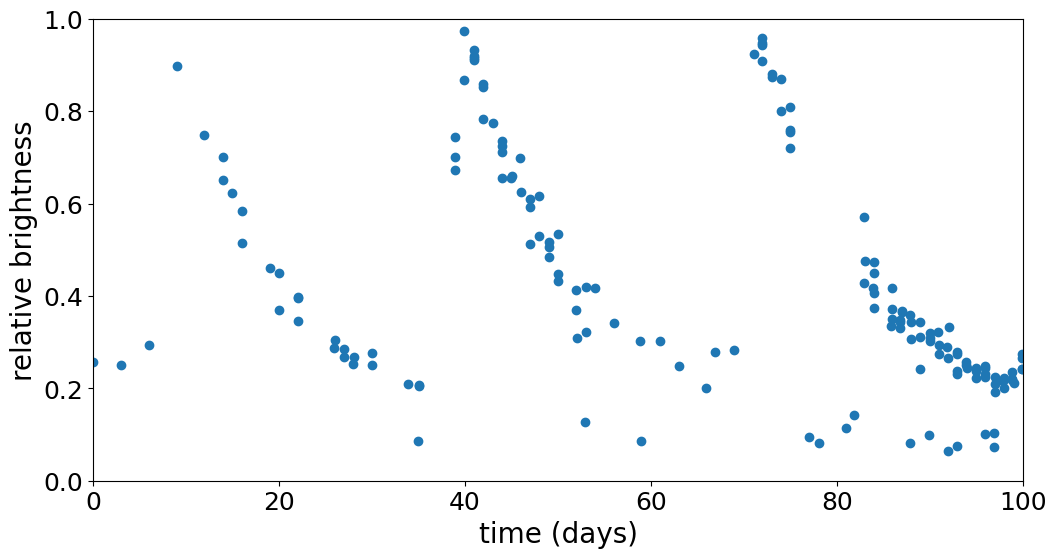

In [173]:
t0 = np.min(mjd)
days = mjd - t0
mag0 = 20.5
deltaMag = mags - mag0
relFlux = 10**(-0.4 * deltaMag)

fig = plt.figure(figsize=(12,6))
plt.scatter(days, relFlux/ np.max(relFlux) / 0.8)
plt.xlim(0,100)
plt.ylim(0,1)
plt.xlabel('time (days)', fontsize=20)
plt.ylabel('relative brightness', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.savefig('BASW1_lightcurve_100days.jpg')



(0.0, 32.0)

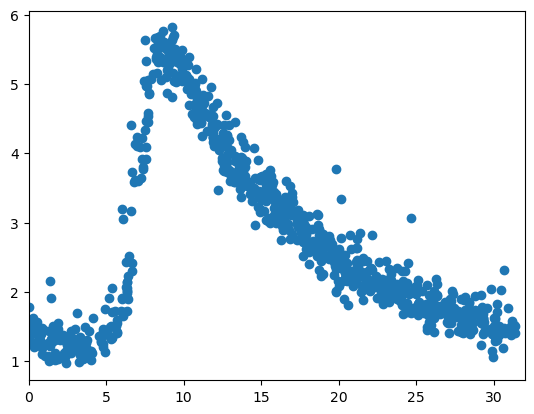

In [39]:
p0 = 31.4013046     # value from ZTF fit

daysInCycle = np.mod(days, p0)
good = (relFlux > 0.9) & (relFlux < 6)

plt.scatter(daysInCycle[good], relFlux[good])
plt.xlim(0,32)


(0.0, 1.0)

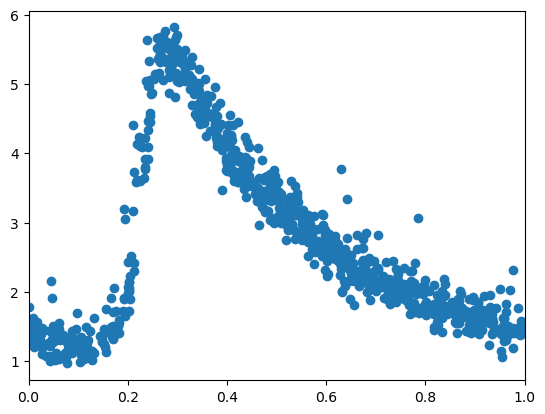

In [59]:
phase = daysInCycle / p0

plt.scatter(phase[good], relFlux[good])
plt.xlim(0,1)


2.6408768 -1.054370328783989 19.44562967121601
19.515701


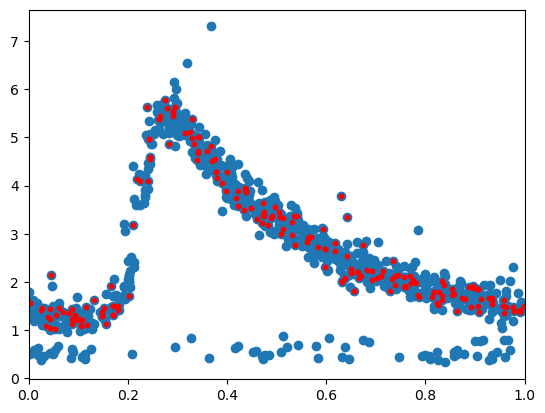

In [147]:
# Calculate mean g' mag by uniformly sampling across phase
#   calculate mean relative flux
#   then convert back into magnitudes

indices = np.where(good)[0]
#sortOrder = np.argsort(phase[indices])
#print(sortOrder)
#print(phase[indices[sortOrder]])
sample = []
rng = np.random.default_rng()

for i in range(20):
    selectRange = (phase[indices] >= i * 0.05) & (phase[indices] < (i+1)*0.05 )
    thisRange = np.where(selectRange)[0]
    #print(i * 0.05, ' to ', (i+1)*0.05, ', ', np.sum(selectRange), 'elements : ', thisRange)
    thisSample = rng.choice(thisRange, 10)    
    #print(i * 0.05, ' to ', (i+1)*0.05, ', selected : ', thisSample)
    sample.append(indices[thisSample])
    
#print(sample)
plt.scatter(phase, relFlux)
plt.scatter(phase[sample], relFlux[sample], c='red', s=10)
plt.xlim(0,1)

meanRelFlux = np.mean(relFlux[sample])
meanDeltaMag = np.log10(meanRelFlux) / (-0.4)
meanMag = meanDeltaMag + mag0
print(meanRelFlux, meanDeltaMag, meanMag)

print(np.mean(mags[good]))

In [161]:
# distance calculated using
# g band PL relationship from: Ngeow, C.-C., Bhardwaj, A., Henderson, J.-Y., et al. 2022, AJ, 164, 154
# m = a log P + b
# g, a = −1.63 ± 0.10, b = −0.07 ± 0.10

g0 = -1.63 * np.log10(p0) - 0.07
deltag = meanMag - g0
print('log P: ', np.log10(p0), 'g0 = ', g0, ' observed gmag = ', meanMag, 'distance modulus: ', deltag)
distance = 10**(deltag / 5 + 1)
print('distance = ', distance, ' pc, or ', distance * 3.26, ' light-years')


log P:  1.4969476916659326 g0 =  -2.5100247374154696  observed gmag =  19.44562967121601 distance modulus:  21.95565440863148
distance =  246110.91877969948  pc, or  802321.5952218203  light-years


In [ ]:
# SpT   Teff  logT   BCv    logL   Mbol R_Rsun   Mv    B-V    Bt-Vt  G-V    Bp-Rp  G-Rp   M_G    b-y    U-B    V-Rc   V-Ic   V-Ks   J-H    H-Ks   M_J    M_Ks   Ks-W1   W1-W2  W1-W3  W1-W4   g-r   i-z  z-Y  Msun  #SpT  
# G2V   5770  3.761 -0.085  0.01   4.72  1.012   4.80  0.650  0.724 -0.165  0.823  0.459  4.635  ...    0.133  0.363  0.713  1.564  0.293  0.073  3.60   3.236  0.061  -0.050 -0.040 -0.016   0.476 ...  ...  1.00  G2V   



In [33]:
# Units

M_earth = 5.97E24
r_earth = 6.37E6
T_earth = 254.0
M_sun = 1.989E30
L_sun = 3.839E26
r_sun = 6.957e8
AU = 1.496E11
pc = 3.086E16
sigma = 5.67E-8
G = 6.67E-11
c = 2.997E8
